In [54]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [55]:
def f(x):
  return 3*x**2 - 4*x +5

In [56]:
f(3.0)

20.0

In [57]:
xs = np.arange(-5,5,0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [58]:
ys=f(xs)

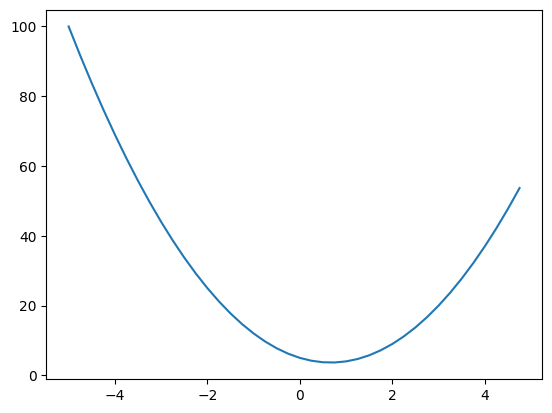

In [59]:
 plt.plot(xs,ys)

In [60]:
h=0.00000001
x=2/3
(f(x+h)-f(x))/h

0.0

In [61]:
a=2.0
b=-3.0
c=10
d=a*b+c
print(d)

4.0


In [62]:
h=0.0001
a=2.0
b=-3.0
c=10

d1=a*b+c
a+=h
d2=a*b+c
print(d1)
print(d2)
print("slope",(d2-d1)/h)

4.0
3.999699999999999
slope -3.000000000010772


In [63]:
h=0.0001
a=2.0
b=-3.0
c=10

d1=a*b+c
b+=h
d2=a*b+c
print(d1)
print(d2)
print("slope",(d2-d1)/h)

4.0
4.0002
slope 2.0000000000042206


In [64]:
h=0.0001
a=2.0
b=-3.0
c=10

d1=a*b+c
c+=h
d2=a*b+c
print(d1)
print(d2)
print("slope",(d2-d1)/h)

4.0
4.0001
slope 0.9999999999976694


In [65]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad=0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label=label


  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += 1.0*out.grad
      other.grad += 1.0*out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += other.data*out.grad
      other.grad += self.data*out.grad
    out._backward = _backward
    return out

  def pow(self,other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')
    def _backward():
      self.grad += other*(self.data**(other-1))*out.grad
    out._backward = _backward
    return out

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    other = other if isinstance(other, Value) else Value(other) # Ensure other is a Value object
    return self * other.pow(-1.0) # Correctly implement division using multiplication and power

  def __sub__(self,other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data - other.data, (self, other), '-')
    # Backward pass for subtraction is similar to addition
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad -= 1.0 * out.grad # Negative gradient for the subtrahend
    out._backward = _backward
    return out


  def tanh(self):
    n = self.data
    t=Value((math.exp(2*n)-1)/(math.exp(2*n)+1))
    out=Value(t.data,(self,),'tanh')
    def _backward():
      self.grad += (1-t.data**2)*out.grad
    out._backward = _backward
    return out

  def exp(self):
    x=self.data
    out=Value(math.exp(x),(self,),'exp')
    def _backward():
      self.grad += out.data*out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo=[]
    visited=set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad=1.0
    for node in reversed(topo):
      node._backward()


a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e=a*b;e.label='e'
d=e+c;d.label='d'
f=Value(-2.0,label='f')
L=d*f;L.label='L'
L

Value(data=-8.0)

In [66]:
a=Value(2.0)
b=Value(4.0)
a-b

Value(data=-2.0)

In [67]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

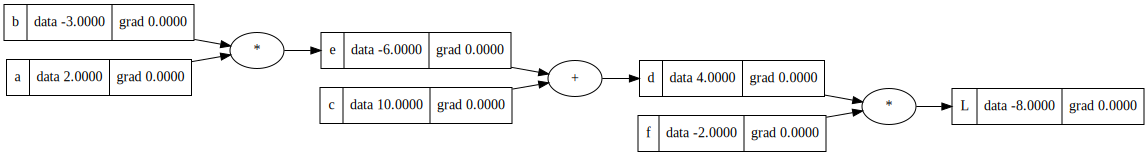

In [68]:
draw_dot(L)

In [69]:
L.grad=1.0
f.grad=4.0
d.grad=-2.0
c.grad=-2.0
e.grad=-2.0
a.grad=6.0
b.grad=-4.0

In [70]:
a.data+= 0.01*a.grad
b.data+= 0.01*b.grad
c.data+= 0.01*c.grad
f.data+= 0.01*f.grad

e=a*b
d=e+c
L=d*f
print(L.data)

-35.549696


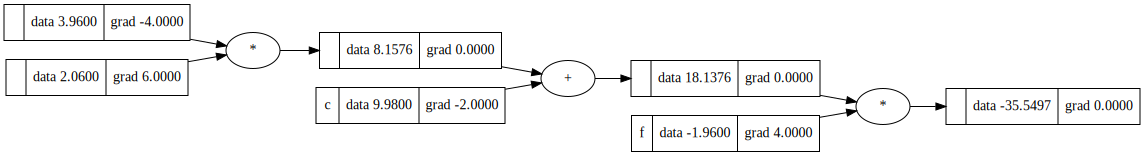

In [71]:
draw_dot(L)

In [72]:
def lol():
  h=0.0001

  a = Value(2.0,label='a')
  b = Value(-3.0,label='b')
  c = Value(10.0,label='c')
  e=a*b;e.label='e'
  d=e+c;d.label='d'
  f=Value(-2.0,label='f')
  L=d*f;L.label='L'
  L1=L.data

  a = Value(2.0,label='a')
  b = Value(-3.0,label='b')
  c = Value(10.0,label='c')
  e=a*b;e.label='e'
  d=e+c;d.label='d'
  f=Value(-2.0,label='f')
  L=d*f;L.label='L'
  L2=L.data+h

  print((L2-L1)/h)
lol()

0.9999999999976694


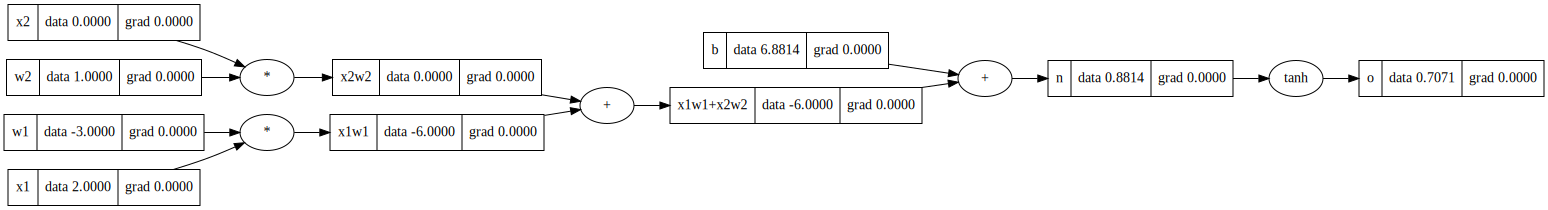

In [73]:
#inputs x1,x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights w1,w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias
b = Value(6.8813735870195432,label='b')

x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1w1+x2w2'
n=x1w1x2w2+b;n.label='n'
o=n.tanh();o.label='o'

draw_dot(o)

In [74]:
o.backward()

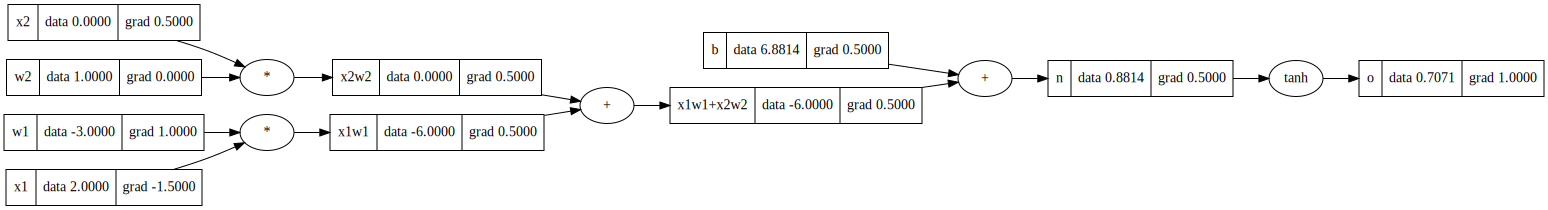

In [75]:
draw_dot(o)

In [76]:
n.grad=(1-(o.data**2))

In [77]:
x1w1x2w2.grad=0.5
b.grad=0.5

In [78]:
x1w1.grad=0.5
x2w2.grad=0.5

In [79]:
x1.grad=w1.data*x1w1.grad
w1.grad=x1.data*x1w1.grad
x2.grad=w2.data*x2w2.grad
w2.grad=x2.data*x2w2.grad

In [80]:
o.grad=1.0


In [81]:
o._backward()

In [82]:
n._backward()

In [83]:
b._backward()

In [84]:
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [85]:
o.grad=1.0

topo=[]
visited=set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

for node in reversed(topo):
  node._backward()

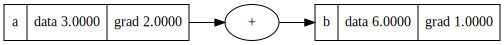

In [86]:
a=Value(3.0,label='a')
b=a+a;b.label='b'
b.backward()
draw_dot(b)

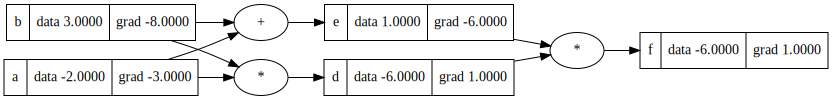

In [87]:
a=Value(-2.0,label='a')
b=Value(3.0,label='b')
d=a*b;d.label='d'
e=a+b;e.label='e'
f=d*e;f.label='f'
f.backward()
draw_dot(f)

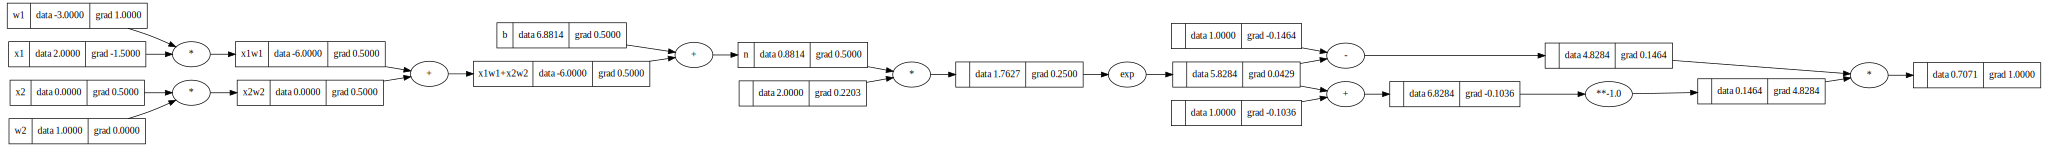

In [88]:
#inputs x1,x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights w1,w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias
b = Value(6.8813735870195432,label='b')

x1w1=x1*w1;x1w1.label='x1w1'
x2w2=x2*w2;x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1w1+x2w2'
n=x1w1x2w2+b;n.label='n'

e=((2*n).exp())
o=(e-1)/(e+1)

o.backward()
draw_dot(o)

In [89]:
#same thing using pytorch
import torch
x1 = torch.Tensor([2.0]).double();x1.requires_grad=True
x2 = torch.Tensor([0.0]).double();x2.requires_grad=True
w1 = torch.Tensor([-3.0]).double();w1.requires_grad=True
w2 = torch.Tensor([1.0]).double();w2.requires_grad=True
b = torch.Tensor([6.8813735870195432]).double();b.requires_grad=True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()
print('---')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [90]:
import random

In [112]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self,x):
    act=__builtins__.sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
    out=act.tanh()
    return out

x=[2.0,3.0]
n = Neuron(2)

n(x)

Value(data=0.8059650033053248)